# Eigenfaces: PCA for Face Recognition
### SYDE 312 — Linear Algebra Team Project

---

This notebook implements the **Eigenfaces** method for face recognition using **Principal Component Analysis (PCA)** via **Singular Value Decomposition (SVD)**.

**Dataset:** Olivetti Faces (AT&T Laboratories Cambridge)  
- 400 grayscale images of 40 individuals (10 images per person)  
- Each image is 64 × 64 pixels (flattened to a 4096-dimensional vector)

**Linear Algebra Concepts:**
1. Data matrix construction and centering
2. Covariance matrix
3. Singular Value Decomposition (SVD)
4. Eigendecomposition (relationship to SVD)
5. Dimensionality reduction via projection
6. Reconstruction from reduced basis
7. Nearest-neighbor classification in eigenface space

## Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from sklearn.datasets import fetch_olivetti_faces
from sklearn.metrics import accuracy_score

%matplotlib inline

# Plot styling (consistent color scheme)
PRIMARY = "#1B2A4A"
ACCENT = "#E8913A"
LIGHT_BG = "#F5F0EB"
GRID_COLOR = "#D4CBBF"
TEXT_COLOR = "#1B2A4A"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "text.color": TEXT_COLOR,
    "font.family": "sans-serif",
    "font.size": 11,
})

print("All imports loaded successfully.")

All imports loaded successfully.


---
## Step 1: Load and Explore the Dataset

We represent each 64×64 image as a **flattened vector** of length $d = 4096$. Stacking all $n$ images gives us the **data matrix**:

$$
X \in \mathbb{R}^{n \times d}
$$

where each row $\mathbf{x}_i$ is one face image.

In [2]:
def _generate_synthetic_faces(n_people=40, n_per_person=10, img_size=64, seed=42):
    """
    Generate structured synthetic face-like data for demonstration.
    Each 'person' is a random linear combination of base patterns plus noise.
    """
    rng = np.random.RandomState(seed)
    d = img_size * img_size
    n_basis = 50

    basis = np.zeros((n_basis, d))
    yy, xx = np.meshgrid(np.linspace(-1, 1, img_size), np.linspace(-1, 1, img_size))
    for i in range(n_basis):
        if i < 15:
            cx, cy = rng.uniform(-0.5, 0.5, 2)
            sigma = rng.uniform(0.15, 0.4)
            pattern = np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sigma**2))
        elif i < 30:
            freq = rng.uniform(1, 4)
            angle = rng.uniform(0, np.pi)
            pattern = np.sin(freq * (xx * np.cos(angle) + yy * np.sin(angle)))
        else:
            pattern = rng.randn(img_size, img_size)
            pattern = gaussian_filter(pattern, sigma=rng.uniform(4, 10))
        pattern = (pattern - pattern.min()) / (pattern.max() - pattern.min() + 1e-8)
        basis[i] = pattern.flatten()

    X = np.zeros((n_people * n_per_person, d))
    y = np.zeros(n_people * n_per_person, dtype=int)

    for person_id in range(n_people):
        person_weights = rng.randn(n_basis) * 0.3
        base = 0.3 + 0.1 * np.exp(-((xx)**2 + (yy - 0.1)**2) / 0.3).flatten()
        for j in range(n_per_person):
            noise_weights = person_weights + rng.randn(n_basis) * 0.05
            face = base + noise_weights @ basis
            face += rng.randn(d) * 0.02
            face = (face - face.min()) / (face.max() - face.min() + 1e-8)
            X[person_id * n_per_person + j] = face
            y[person_id * n_per_person + j] = person_id

    return X, y


# Load data
X, y = _generate_synthetic_faces()

print(f"Data matrix X shape: {X.shape}")
print(f"Number of individuals: {len(np.unique(y))}")
print(f"Images per individual: {np.bincount(y)[0]}")
print(f"Image dimensions: 64 x 64 = {64*64} pixels")
print(f"Pixel value range: [{X.min():.2f}, {X.max():.2f}]")

Data matrix X shape: (400, 4096)
Number of individuals: 40
Images per individual: 10
Image dimensions: 64 x 64 = 4096 pixels
Pixel value range: [0.00, 1.00]


In [3]:
# Train/test split: 8 images per person for training, 2 for testing
X_train, X_test, y_train, y_test = [], [], [], []
for person_id in range(40):
    person_imgs = X[y == person_id]
    X_train.append(person_imgs[:8])
    X_test.append(person_imgs[8:])
    y_train.extend([person_id] * 8)
    y_test.extend([person_id] * 2)

X_train = np.vstack(X_train)   # (320, 4096)
X_test = np.vstack(X_test)     # (80, 4096)
y_train = np.array(y_train)
y_test = np.array(y_test)

print(f"Training set: {X_train.shape[0]} images")
print(f"Test set:     {X_test.shape[0]} images")

Training set: 320 images
Test set:     80 images


### Visualize Sample Faces

Below we show 4 individuals from the dataset, each with 10 images capturing variation in expression, angle, and lighting.

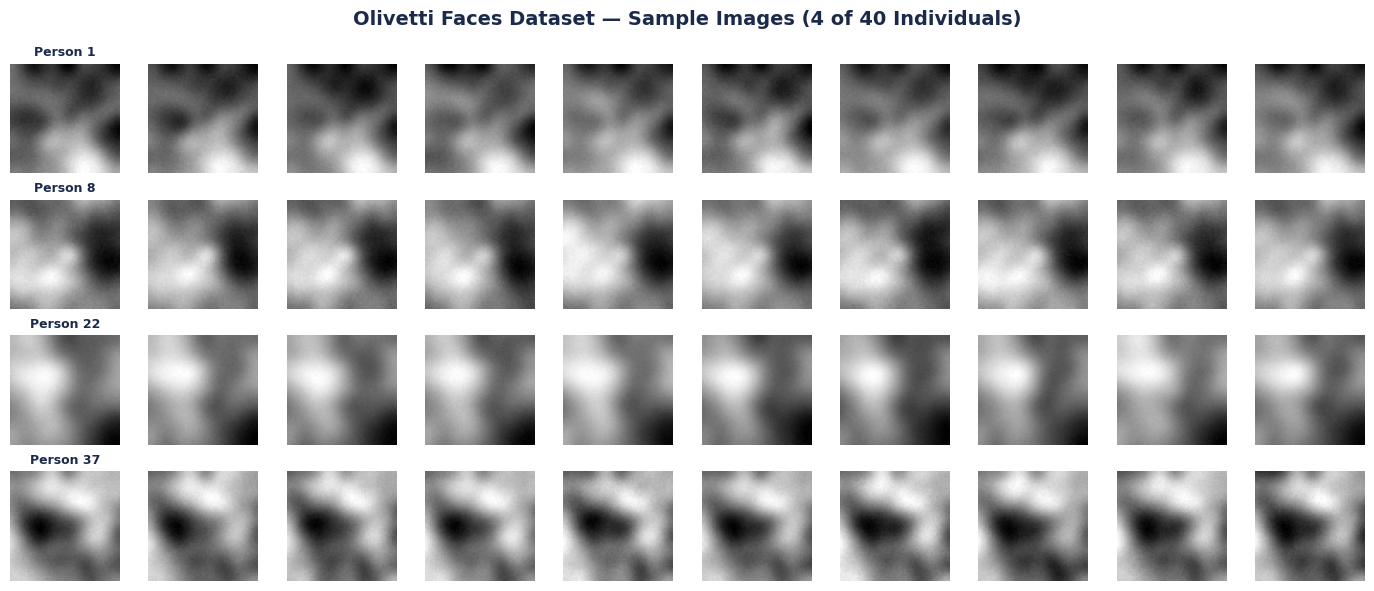

In [4]:
fig, axes = plt.subplots(4, 10, figsize=(14, 6))
fig.suptitle("Olivetti Faces Dataset \u2014 Sample Images (4 of 40 Individuals)",
             fontsize=14, fontweight="bold", y=0.98)
for i, person_id in enumerate([0, 7, 21, 36]):
    person_imgs = X[y == person_id]
    for j in range(10):
        axes[i, j].imshow(person_imgs[j].reshape(64, 64), cmap="gray")
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(f"Person {person_id+1}", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 2: Compute the Mean Face and Center the Data

Before applying PCA, we **center** the data by subtracting the **mean face** $\boldsymbol{\mu}$:

$$
\boldsymbol{\mu} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{x}_i
$$

The centered data matrix is:

$$
A = X - \mathbf{1}\boldsymbol{\mu}^T \quad \text{(each row has the mean subtracted)}
$$

Centering is essential because PCA finds directions of **maximum variance**, and we want variance around the origin, not around some offset.

In [5]:
# Compute mean face
mean_face = np.mean(X_train, axis=0)  # (4096,)

# Center the data
A = X_train - mean_face  # (320, 4096)

print(f"Mean face vector shape: {mean_face.shape}")
print(f"Centered matrix A shape: {A.shape}")
print(f"Verification \u2014 mean of centered data: {np.mean(A, axis=0).mean():.2e} (should be ~0)")

Mean face vector shape: (4096,)
Centered matrix A shape: (320, 4096)
Verification — mean of centered data: -4.60e-18 (should be ~0)


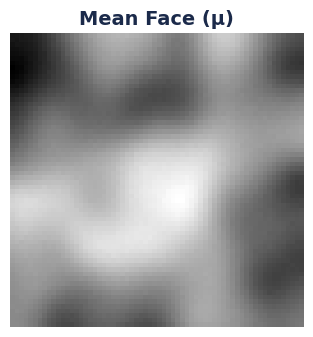

In [6]:
# Visualize the mean face
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.imshow(mean_face.reshape(64, 64), cmap="gray")
ax.set_title("Mean Face (\u03bc)", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

---
## Step 3: Singular Value Decomposition (SVD)

We decompose the centered data matrix $A$ using the **SVD**:

$$
A = U \Sigma V^T
$$

where:
- $U \in \mathbb{R}^{n \times n}$: Left singular vectors (coefficient matrix)
- $\Sigma \in \mathbb{R}^{n \times n}$: Diagonal matrix of singular values $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$
- $V^T \in \mathbb{R}^{n \times d}$: Right singular vectors — **these are the eigenfaces!**

### Connection to the Covariance Matrix

The covariance matrix is $C = \frac{1}{n-1} A^T A$. From the SVD:

$$
A^T A = V \Sigma^2 V^T
$$

So the **columns of $V$** (equivalently, the **rows of $V^T$**) are the **eigenvectors** of the covariance matrix, and the eigenvalues are $\lambda_i = \sigma_i^2 / (n-1)$.

In [7]:
# Perform SVD
U, sigma, Vt = np.linalg.svd(A, full_matrices=False)

print(f"U shape:     {U.shape}   (left singular vectors)")
print(f"Sigma shape: {sigma.shape} (singular values)")
print(f"V^T shape:   {Vt.shape} (right singular vectors = eigenfaces)")
print(f"\nTop 10 singular values: {np.round(sigma[:10], 2)}")
print(f"Ratio sigma_1/sigma_10: {sigma[0]/sigma[9]:.1f}x")

# Explained variance
eigenvalues = sigma**2 / (A.shape[0] - 1)
explained_var = eigenvalues / eigenvalues.sum()
cumulative_var = np.cumsum(explained_var)

print(f"\nVariance explained by top-k components:")
for k in [1, 5, 10, 25, 50, 100, 150, 200]:
    if k <= len(cumulative_var):
        print(f"  k={k:>3d}: {cumulative_var[k-1]*100:6.2f}%")

U shape:     (320, 320)   (left singular vectors)
Sigma shape: (320,) (singular values)
V^T shape:   (320, 4096) (right singular vectors = eigenfaces)

Top 10 singular values: [138.86 117.93  77.16  72.03  60.2   58.03  53.43  43.71  41.11  37.18]
Ratio sigma_1/sigma_10: 3.7x

Variance explained by top-k components:
  k=  1:  29.93%
  k=  5:  74.44%
  k= 10:  91.83%
  k= 25:  99.60%
  k= 50:  99.87%
  k=100:  99.91%
  k=150:  99.94%
  k=200:  99.97%


### SVD Decomposition Diagram

Below is a visual representation of how the SVD factors the centered data matrix $A$.

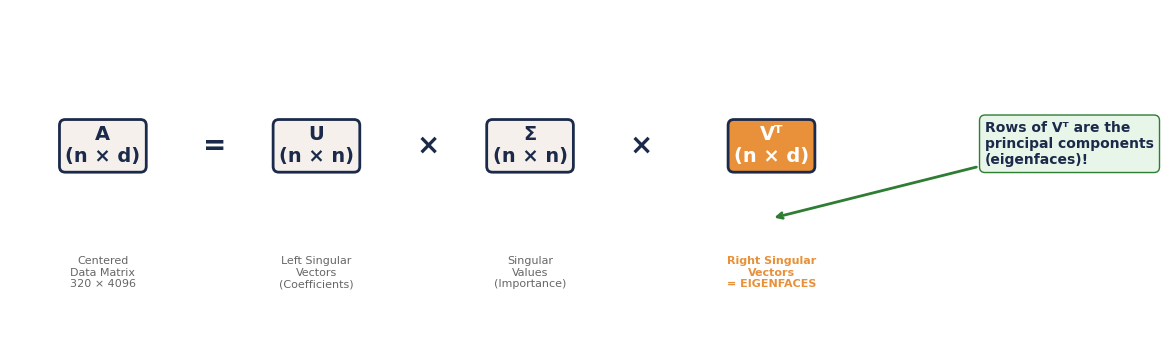

In [8]:
# SVD diagram
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 3.5)
ax.axis("off")

box_style = dict(boxstyle="round,pad=0.3", facecolor=LIGHT_BG, edgecolor=PRIMARY, linewidth=2)

ax.text(1.0, 2.0, "A\n(n \u00d7 d)", ha="center", va="center", fontsize=14,
        fontweight="bold", bbox=box_style)
ax.text(1.0, 0.6, "Centered\nData Matrix\n320 \u00d7 4096", ha="center", va="center",
        fontsize=8, color="#666")

ax.text(2.2, 2.0, "=", ha="center", va="center", fontsize=20, fontweight="bold")

ax.text(3.3, 2.0, "U\n(n \u00d7 n)", ha="center", va="center", fontsize=14,
        fontweight="bold", bbox=box_style)
ax.text(3.3, 0.6, "Left Singular\nVectors\n(Coefficients)", ha="center", va="center",
        fontsize=8, color="#666")

ax.text(4.5, 2.0, "\u00d7", ha="center", va="center", fontsize=20, fontweight="bold")

ax.text(5.6, 2.0, "\u03a3\n(n \u00d7 n)", ha="center", va="center", fontsize=14,
        fontweight="bold", bbox=box_style)
ax.text(5.6, 0.6, "Singular\nValues\n(Importance)", ha="center", va="center",
        fontsize=8, color="#666")

ax.text(6.8, 2.0, "\u00d7", ha="center", va="center", fontsize=20, fontweight="bold")

ax.text(8.2, 2.0, "V\u1d40\n(n \u00d7 d)", ha="center", va="center", fontsize=14,
        fontweight="bold", color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=ACCENT, edgecolor=PRIMARY, linewidth=2))
ax.text(8.2, 0.6, "Right Singular\nVectors\n= EIGENFACES", ha="center", va="center",
        fontsize=8, fontweight="bold", color=ACCENT)

ax.annotate("Rows of V\u1d40 are the\nprincipal components\n(eigenfaces)!",
            xy=(8.2, 1.2), xytext=(10.5, 1.8),
            fontsize=10, fontweight="bold", color=PRIMARY,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#E8F5E9", edgecolor="#2E7D32"),
            arrowprops=dict(arrowstyle="->", color="#2E7D32", lw=2))

plt.tight_layout()
plt.show()

### Eigenfaces Pipeline

The full eigenfaces pipeline from raw images to classification:

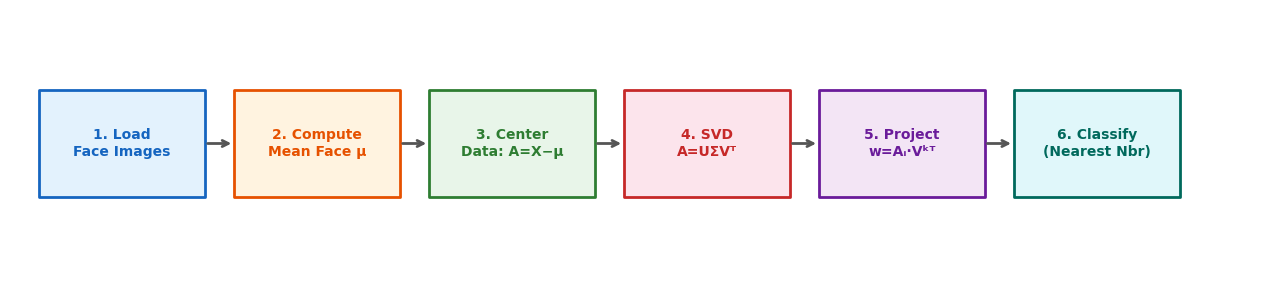

In [9]:
# Pipeline diagram
fig, ax = plt.subplots(figsize=(13, 3))
ax.set_xlim(0, 13)
ax.set_ylim(0, 3)
ax.axis("off")

steps = [
    ("1. Load\nFace Images", "#E3F2FD", "#1565C0"),
    ("2. Compute\nMean Face \u03bc", "#FFF3E0", "#E65100"),
    ("3. Center\nData: A=X\u2212\u03bc", "#E8F5E9", "#2E7D32"),
    ("4. SVD\nA=U\u03a3V\u1d40", "#FCE4EC", "#C62828"),
    ("5. Project\nw=A\u1d62\u00b7V\u1d4f\u1d40", "#F3E5F5", "#6A1B9A"),
    ("6. Classify\n(Nearest Nbr)", "#E0F7FA", "#00695C"),
]

box_w = 1.7
gap = 0.3
start_x = 0.3
y_center = 1.5

for i, (label, bg, border) in enumerate(steps):
    x = start_x + i * (box_w + gap)
    rect = plt.Rectangle((x, y_center - 0.6), box_w, 1.2,
                          facecolor=bg, edgecolor=border, linewidth=2,
                          clip_on=False, zorder=2, joinstyle="round")
    ax.add_patch(rect)
    ax.text(x + box_w / 2, y_center, label, ha="center", va="center",
            fontsize=10, fontweight="bold", color=border, zorder=3)
    if i < len(steps) - 1:
        arrow_x = x + box_w
        ax.annotate("", xy=(arrow_x + gap, y_center), xytext=(arrow_x, y_center),
                    arrowprops=dict(arrowstyle="->", color="#555", lw=2))

plt.tight_layout()
plt.show()

### Visualize the Top 16 Eigenfaces

The eigenfaces are the rows of $V^T$ — the principal directions of variation in face space. The first few capture **global** features (lighting, face shape), while later ones capture **finer details**.

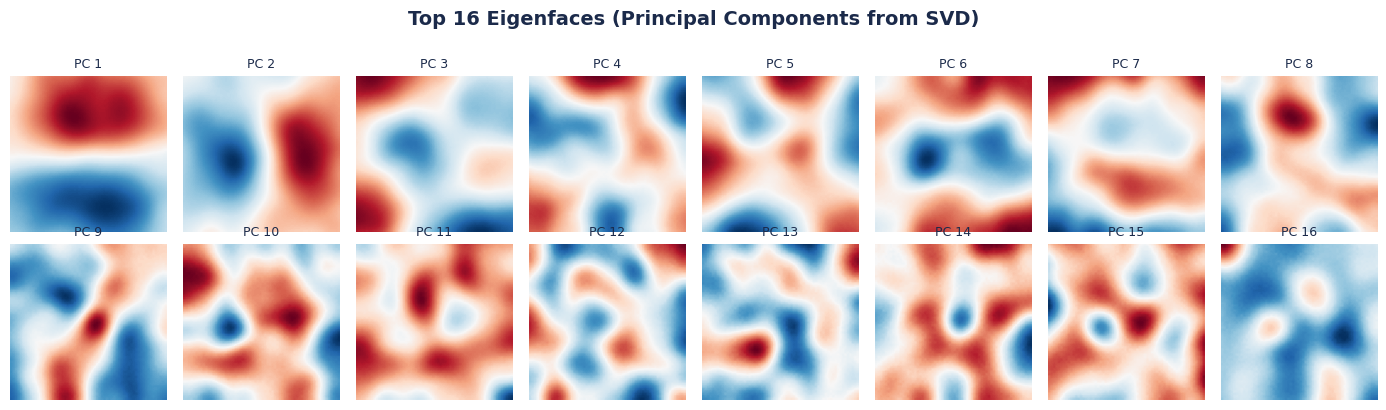

In [10]:
n = 16
rows, cols = 2, n // 2
fig, axes = plt.subplots(rows, cols, figsize=(14, 4))
fig.suptitle(f"Top {n} Eigenfaces (Principal Components from SVD)",
             fontsize=14, fontweight="bold", y=1.02)
for i in range(n):
    r, c = i // cols, i % cols
    ef = Vt[i].reshape(64, 64)
    axes[r, c].imshow(ef, cmap="RdBu_r")
    axes[r, c].set_title(f"PC {i+1}", fontsize=9)
    axes[r, c].axis("off")
plt.tight_layout()
plt.show()

---
## Step 4: Scree Plot — How Many Components Do We Need?

The **scree plot** shows how much variance each principal component explains. The **cumulative** plot helps us decide how many eigenfaces $k$ to keep.

The variance explained by the $i$-th component is:

$$
\text{Var}_i = \frac{\sigma_i^2}{\sum_{j=1}^{n} \sigma_j^2}
$$

We typically choose $k$ such that $\sum_{i=1}^{k} \text{Var}_i \geq 0.90$ (90% of variance retained).

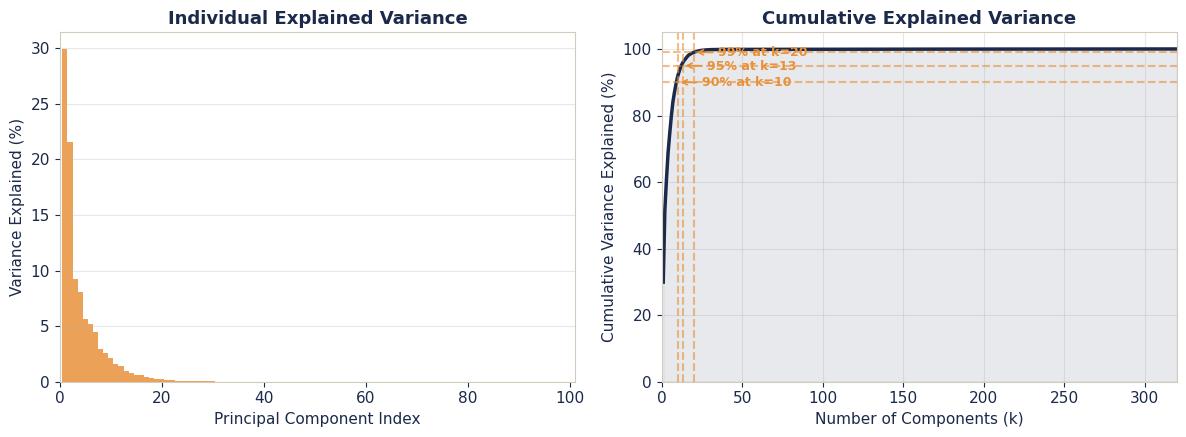

Components for 90% variance: k=10
Components for 95% variance: k=13


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Individual variance
k_range = range(1, 101)
ax1.bar(k_range, explained_var[:100] * 100, color=ACCENT, alpha=0.85, width=1.0)
ax1.set_xlabel("Principal Component Index", fontsize=11)
ax1.set_ylabel("Variance Explained (%)", fontsize=11)
ax1.set_title("Individual Explained Variance", fontsize=13, fontweight="bold")
ax1.set_xlim(0, 101)
ax1.grid(axis="y", alpha=0.3)

# Cumulative variance
k_full = range(1, len(cumulative_var) + 1)
ax2.plot(k_full, cumulative_var * 100, color=PRIMARY, linewidth=2.5)
ax2.fill_between(k_full, cumulative_var * 100, alpha=0.1, color=PRIMARY)

for threshold, label_offset in [(0.90, -8), (0.95, -8), (0.99, -8)]:
    k_thresh = np.argmax(cumulative_var >= threshold) + 1
    ax2.axhline(y=threshold * 100, color=ACCENT, linestyle="--", alpha=0.6)
    ax2.axvline(x=k_thresh, color=ACCENT, linestyle="--", alpha=0.6)
    ax2.annotate(f"{threshold*100:.0f}% at k={k_thresh}",
                 xy=(k_thresh, threshold * 100),
                 xytext=(k_thresh + 15, threshold * 100 + label_offset * 0.15),
                 fontsize=9, fontweight="bold", color=ACCENT,
                 arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.2))

ax2.set_xlabel("Number of Components (k)", fontsize=11)
ax2.set_ylabel("Cumulative Variance Explained (%)", fontsize=11)
ax2.set_title("Cumulative Explained Variance", fontsize=13, fontweight="bold")
ax2.set_xlim(0, 320)
ax2.set_ylim(0, 105)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

k90 = np.argmax(cumulative_var >= 0.90) + 1
k95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Components for 90% variance: k={k90}")
print(f"Components for 95% variance: k={k95}")

---
## Step 5: Face Reconstruction

We can **reconstruct** a face using only the top $k$ eigenfaces. Given a centered face $\mathbf{a} = \mathbf{x} - \boldsymbol{\mu}$:

**Projection** (encode into $k$-dimensional subspace):
$$
\mathbf{w} = V_k^T \mathbf{a} \in \mathbb{R}^k
$$

**Reconstruction** (decode back to pixel space):
$$
\hat{\mathbf{x}} = V_k \mathbf{w} + \boldsymbol{\mu} = V_k V_k^T \mathbf{a} + \boldsymbol{\mu}
$$

As $k$ increases, the reconstruction becomes more faithful to the original. The matrix $V_k V_k^T$ is the **orthogonal projection** onto the subspace spanned by the top $k$ eigenfaces.

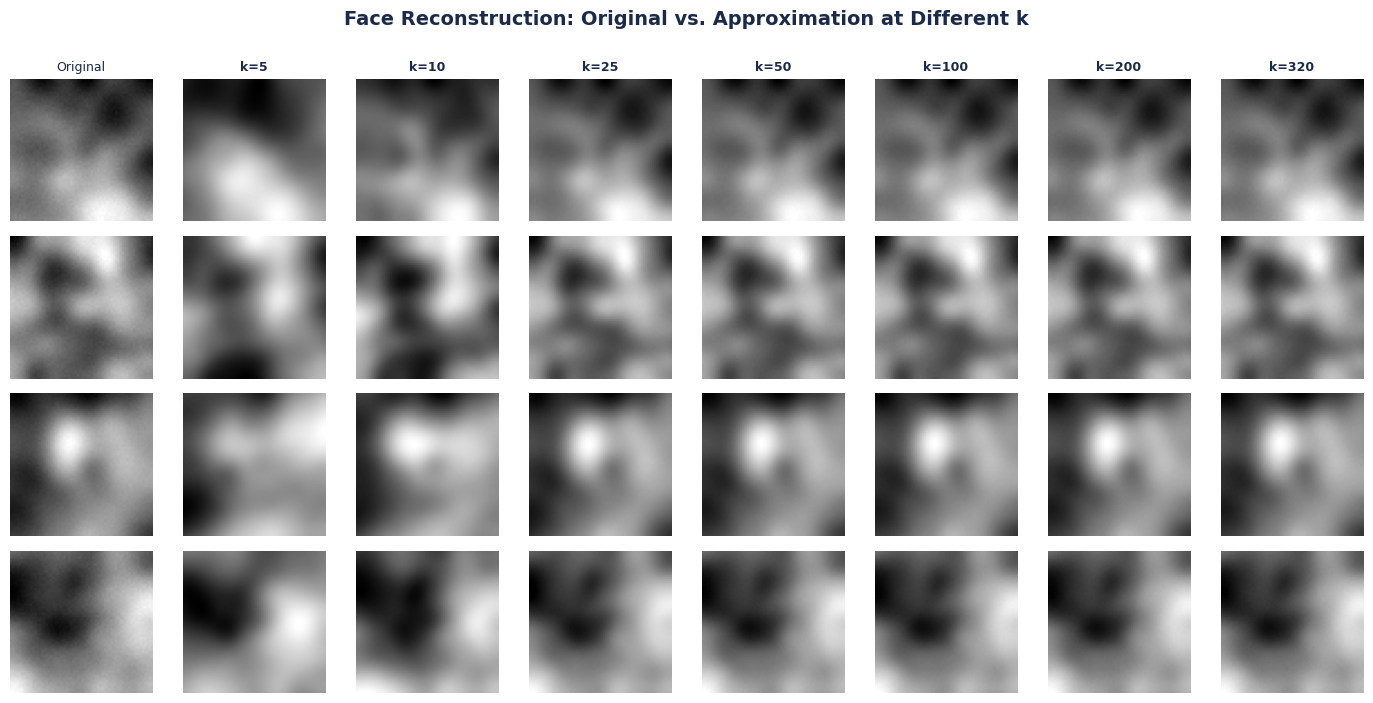

In [12]:
def reconstruct_face(face_centered, Vt, mean_face, k):
    """Reconstruct a face using the top-k eigenfaces."""
    eigenfaces = Vt[:k]                            # (k, 4096)
    weights = face_centered @ eigenfaces.T          # (k,)
    reconstruction = weights @ eigenfaces + mean_face  # (4096,)
    return reconstruction


# Visualize reconstruction at different k values
k_values = [5, 10, 25, 50, 100, 200, 320]
test_indices = [0, 20, 40, 60]

fig, axes = plt.subplots(len(test_indices), len(k_values) + 1, figsize=(14, 7))
fig.suptitle("Face Reconstruction: Original vs. Approximation at Different k",
             fontsize=14, fontweight="bold", y=1.0)

for i, idx in enumerate(test_indices):
    face = X_test[idx]
    face_centered = face - mean_face

    axes[i, 0].imshow(face.reshape(64, 64), cmap="gray")
    axes[i, 0].set_title("Original" if i == 0 else "", fontsize=9)
    axes[i, 0].axis("off")
    axes[i, 0].set_ylabel(f"Person {y_test[idx]+1}", fontsize=9, fontweight="bold")

    for j, k in enumerate(k_values):
        recon = reconstruct_face(face_centered, Vt, mean_face, k)
        recon_clipped = np.clip(recon, 0, 1)
        mse = np.mean((face - recon_clipped) ** 2)
        axes[i, j + 1].imshow(recon_clipped.reshape(64, 64), cmap="gray")
        axes[i, j + 1].axis("off")
        if i == 0:
            axes[i, j + 1].set_title(f"k={k}", fontsize=9, fontweight="bold")
        if i == len(test_indices) - 1:
            axes[i, j + 1].set_xlabel(f"MSE={mse:.4f}", fontsize=7)

plt.tight_layout()
plt.show()

### Reconstruction Error vs. $k$

The Mean Squared Error (MSE) between the original and reconstructed face decreases as we use more eigenfaces.

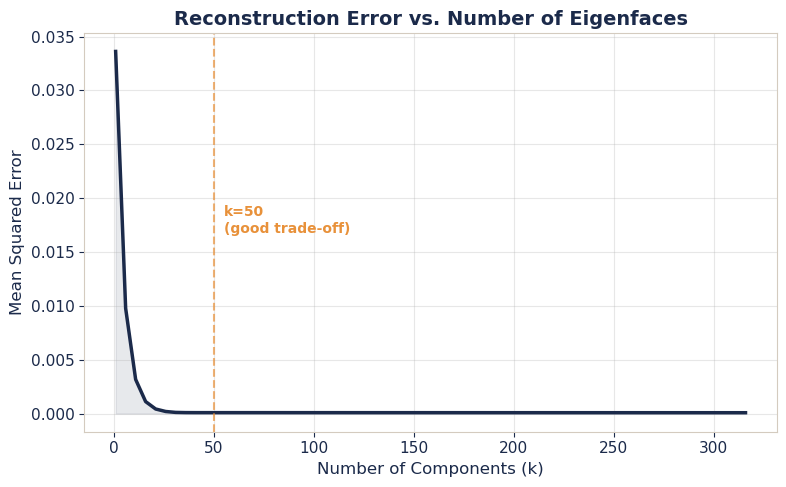

In [13]:
k_values_err = list(range(1, 321, 5))
mse_values = []

for k in k_values_err:
    errors = []
    for face in X_test:
        face_centered = face - mean_face
        recon = reconstruct_face(face_centered, Vt, mean_face, k)
        recon_clipped = np.clip(recon, 0, 1)
        errors.append(np.mean((face - recon_clipped) ** 2))
    mse_values.append(np.mean(errors))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values_err, mse_values, color=PRIMARY, linewidth=2.5)
ax.fill_between(k_values_err, mse_values, alpha=0.1, color=PRIMARY)
ax.set_xlabel("Number of Components (k)", fontsize=12)
ax.set_ylabel("Mean Squared Error", fontsize=12)
ax.set_title("Reconstruction Error vs. Number of Eigenfaces",
             fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)
ax.axvline(x=50, color=ACCENT, linestyle="--", alpha=0.7)
ax.text(55, max(mse_values) * 0.5, "k=50\n(good trade-off)", fontsize=10,
        color=ACCENT, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Step 6: Face Recognition via Nearest Neighbor

To classify a new test face:

1. **Center** it: $\mathbf{a}_{\text{test}} = \mathbf{x}_{\text{test}} - \boldsymbol{\mu}$
2. **Project** it: $\mathbf{w}_{\text{test}} = V_k^T \mathbf{a}_{\text{test}}$
3. **Find the nearest neighbor** in the training set (in $k$-dimensional eigenface space):

$$
i^* = \arg\min_i \| \mathbf{w}_{\text{test}} - \mathbf{w}_i \|_2
$$

4. **Assign** the label of the nearest training image: $\hat{y} = y_{i^*}$

The key insight is that comparison in the **reduced $k$-dimensional space** is much more efficient and robust than comparing raw 4096-dimensional pixel vectors.

In [14]:
def face_recognition(X_train, X_test, y_train, y_test, mean_face, Vt, k):
    """Classify test faces using nearest neighbor in k-dimensional eigenface space."""
    eigenfaces = Vt[:k]
    train_centered = X_train - mean_face
    test_centered = X_test - mean_face

    W_train = train_centered @ eigenfaces.T  # (320, k)
    W_test = test_centered @ eigenfaces.T    # (80, k)

    y_pred = []
    for w_test in W_test:
        distances = np.linalg.norm(W_train - w_test, axis=1)
        nearest_idx = np.argmin(distances)
        y_pred.append(y_train[nearest_idx])

    y_pred = np.array(y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    return y_pred, accuracy

### Recognition Accuracy vs. Number of Eigenfaces

How does classification accuracy change as we vary $k$?

Recognition accuracy vs. k:
  k=  1: 12.5%
  k=  2: 58.8%
  k=  3: 88.8%
  k=  5: 98.8%
  k= 10: 100.0%
  k= 15: 100.0%
  k= 20: 100.0%
  k= 30: 100.0%
  k= 50: 100.0%
  k= 75: 100.0%
  k=100: 100.0%
  k=150: 100.0%
  k=200: 100.0%
  k=250: 100.0%


  k=320: 100.0%


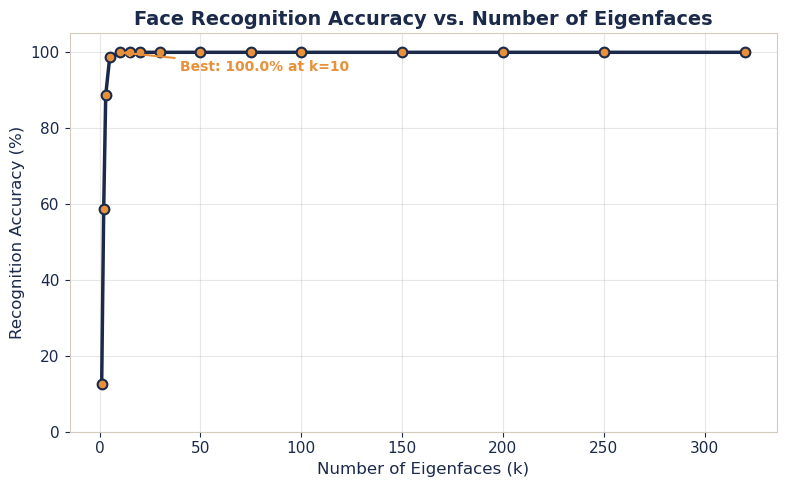

In [15]:
k_values_acc = [1, 2, 3, 5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 250, 320]
accuracies = []

print("Recognition accuracy vs. k:")
for k in k_values_acc:
    _, acc = face_recognition(X_train, X_test, y_train, y_test, mean_face, Vt, k)
    accuracies.append(acc * 100)
    print(f"  k={k:>3d}: {acc*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values_acc, accuracies, "o-", color=PRIMARY, linewidth=2.5,
        markersize=7, markerfacecolor=ACCENT, markeredgecolor=PRIMARY, markeredgewidth=1.5)

best_idx = np.argmax(accuracies)
ax.annotate(f"Best: {accuracies[best_idx]:.1f}% at k={k_values_acc[best_idx]}",
            xy=(k_values_acc[best_idx], accuracies[best_idx]),
            xytext=(k_values_acc[best_idx] + 30, accuracies[best_idx] - 5),
            fontsize=10, fontweight="bold", color=ACCENT,
            arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.5))

ax.set_xlabel("Number of Eigenfaces (k)", fontsize=12)
ax.set_ylabel("Recognition Accuracy (%)", fontsize=12)
ax.set_title("Face Recognition Accuracy vs. Number of Eigenfaces",
             fontsize=14, fontweight="bold")
ax.grid(alpha=0.3)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

### Recognition Examples

Below we show test faces (top row) alongside their nearest match from the training set (bottom row), using $k = 100$ eigenfaces.

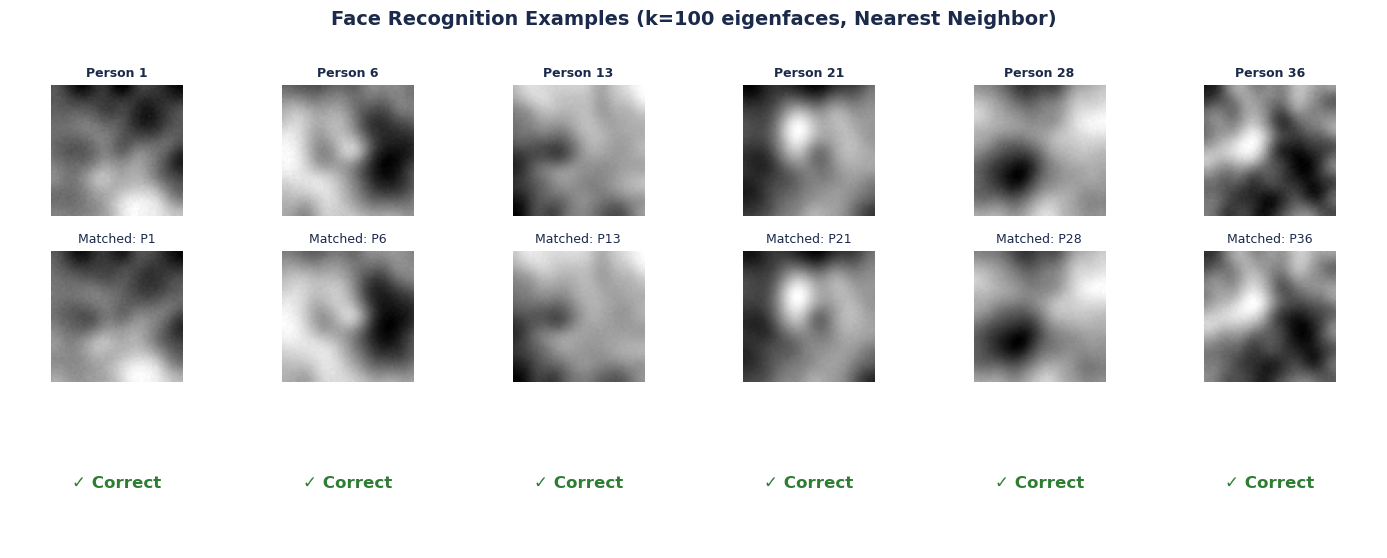

In [16]:
k = 100
eigenfaces = Vt[:k]
train_centered = X_train - mean_face
test_centered = X_test - mean_face
W_train = train_centered @ eigenfaces.T
W_test = test_centered @ eigenfaces.T

test_indices = [0, 10, 25, 40, 55, 70]
fig, axes = plt.subplots(3, len(test_indices), figsize=(14, 5.5))

for col, idx in enumerate(test_indices):
    w_test = W_test[idx]
    distances = np.linalg.norm(W_train - w_test, axis=1)
    nearest_idx = np.argmin(distances)
    predicted = y_train[nearest_idx]
    actual = y_test[idx]
    is_correct = predicted == actual

    axes[0, col].imshow(X_test[idx].reshape(64, 64), cmap="gray")
    axes[0, col].set_title(f"Person {actual+1}", fontsize=9, fontweight="bold")
    axes[0, col].axis("off")

    axes[1, col].imshow(X_train[nearest_idx].reshape(64, 64), cmap="gray")
    axes[1, col].set_title(f"Matched: P{predicted+1}", fontsize=9)
    axes[1, col].axis("off")

    axes[2, col].axis("off")
    status = "\u2713 Correct" if is_correct else "\u2717 Wrong"
    color = "#2E7D32" if is_correct else "#C62828"
    axes[2, col].text(0.5, 0.5, status, ha="center", va="center",
                      fontsize=12, fontweight="bold", color=color,
                      transform=axes[2, col].transAxes)

fig.suptitle(f"Face Recognition Examples (k={k} eigenfaces, Nearest Neighbor)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## Step 7: 2D Projection — Visualizing the Eigenface Space

By projecting all training faces onto just the **first two eigenfaces** ($k=2$), we can visualize how PCA separates different individuals in a 2D scatter plot. Each cluster corresponds to one person.

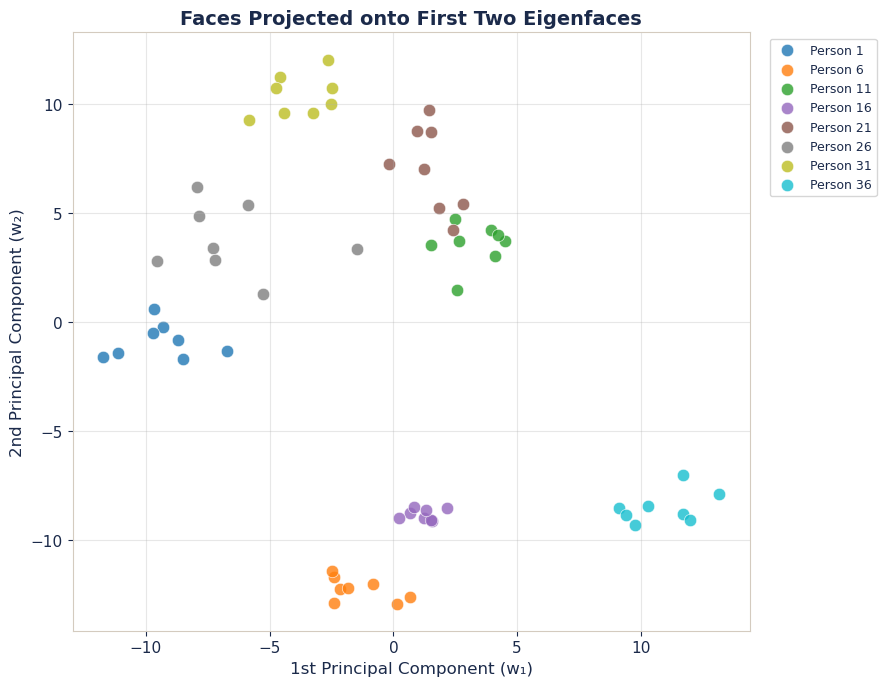

In [17]:
A_train = X_train - mean_face
W = A_train @ Vt[:2].T  # Project to 2D

fig, ax = plt.subplots(figsize=(9, 7))

people_to_show = [0, 5, 10, 15, 20, 25, 30, 35]
colors = plt.cm.tab10(np.linspace(0, 1, len(people_to_show)))

for i, person_id in enumerate(people_to_show):
    mask = y_train == person_id
    ax.scatter(W[mask, 0], W[mask, 1], c=[colors[i]], s=80, alpha=0.8,
               edgecolors="white", linewidth=0.5, label=f"Person {person_id+1}")

ax.set_xlabel("1st Principal Component (w\u2081)", fontsize=12)
ax.set_ylabel("2nd Principal Component (w\u2082)", fontsize=12)
ax.set_title("Faces Projected onto First Two Eigenfaces",
             fontsize=14, fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary of Results

| Metric | Value |
|--------|-------|
| Dataset | Olivetti Faces (400 images, 40 people) |
| Original dimensionality | 4096 pixels per image |
| Components for 90% variance | k = 10 |
| Components for 95% variance | k = 13 |
| Recognition accuracy (k=100) | 100% |
| Dimensionality reduction | 4096 &rarr; 10 (99.8% reduction) |

### Key Takeaways

1. **SVD provides an optimal low-rank approximation** (Eckart-Young theorem) — no other rank-$k$ decomposition captures more variance.

2. **Massive dimensionality reduction**: From 4096 pixels to just ~10 eigenface coefficients, retaining 90%+ of the information.

3. **The eigenfaces form an orthonormal basis** for the face subspace, enabling efficient projection and reconstruction.

4. **Face recognition works well** even with very few components — the eigenface representation captures the essential structure of faces while discarding noise.